# TRAS - C60 Quenched

### Mounting the google drive

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [3]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
#pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/C60_17Mar2026' #Sara's directory
pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/TRAS/TRAS/C60_17Mar2026' #Fin's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['BZbb1 2026-03-17 11-36-15 TA.csv', 'BZbb1 2026-03-17 11-36-15 TA_traces.csv', 'BZbb1 2026-03-17 11-36-15 TA.xml', 'BZbb075 2026-03-17 11-46-30 TA_traces.csv', 'BZbb075 2026-03-17 11-46-30 TA.csv', 'BZbb075 2026-03-17 11-46-30 TA.xml', 'BZbb05 2026-03-17 12-20-16 TA_traces.csv', 'BZbb05 2026-03-17 12-20-16 TA.xml', 'BZbb05 2026-03-17 12-20-16 TA.csv', 'BZbb025 2026-03-17 14-50-42 TA_traces.csv', 'BZbb025 2026-03-17 14-50-42 TA.csv', 'BZbb025 2026-03-17 14-50-42 TA.xml', 'BZbb1 2026-03-17 11-36-15 TA_Bootstrap_Distribution.png', 'BZbb1 2026-03-17 11-36-15 TA_signal_vs_time.png', 'BZbb05 2026-03-17 12-20-16 TA_Bootstrap_Distribution.png', 'BZbb05 2026-03-17 12-20-16 TA_signal_vs_time.png', 'BZbb025 2026-03-17 14-50-42 TA_Bootstrap_Distribution.png', 'BZbb025 2026-03-17 14-50-42 TA_signal_vs_time.png', 'C60_SternVolmer.png', 'BZbb075 2026-03-17 11-46-30 TA_Bootstrap_Distribution.png', 'BZbb075 2026-03-17 11-46-30 TA_signal_vs_time.png', 'BZbb025 2026-03-17 14-50-42 TA_full_analysis.png',

## Loading and cleaning data
This step removes the negative bits before the exponential decay.

In [4]:
csv_title = 'BZbb075 2026-03-17 11-46-30 TA.csv' #Modify this
clean_title = csv_title.replace(".csv", "")

df = pd.read_csv(
    os.path.join(pathTRAS, csv_title),
    sep=";",
    header=None,
    names=["time", "signal"]
)

df.head()

df = df.iloc[1:].reset_index(drop=True)
df = df.astype(float)

# index of maximum signal
idx_peak = df["signal"].idxmax()
df = df.loc[idx_peak:].reset_index(drop=True)


time = df["time"].to_numpy()
signal = df["signal"].to_numpy()

## Fitting an exponential

Bootstrap Bill

In [5]:
# Exponential fit
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

# Data - signal against time
x = time
y = signal

# Initial guesses based on max and min of dataset and bounds
A_init = y.max() - y.min()
tau_init = (x.max() - x.min()) / 5
C_init = y.min()
p0 = [A_init, tau_init, C_init] # Combined parameter for the 3 values
bounds = ([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf])

# Fit the exponential curve on the dataset and obtain error from covariance matrix
popt, pcov = curve_fit(exp_decay, x, y, p0=p0, bounds=bounds)
A, tau, C = popt
param_error = np.sqrt(np.diag(pcov))
A_error, tau_error, C_error = param_error

# Residuals
y_fit_data = exp_decay(x, *popt)
residuals = y - y_fit_data

# Bootstrapping
n_boot = 5000
tau_boot = []

for _ in range(n_boot):
    # Resample residuals with replacement
    resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)

    # Generate bootstrap dataset
    y_boot = y_fit_data + resampled_residuals

    try:
        # Refit
        popt_boot, _ = curve_fit(exp_decay, x, y_boot, p0=popt, bounds=bounds)
        tau_boot.append(popt_boot[1])
    except RuntimeError:
        # Skip failed fits
        continue

tau_boot = np.array(tau_boot)

# --- Bootstrap statistics ---
tau_std = np.std(tau_boot)
ci_low, ci_high = np.percentile(tau_boot, [2.5, 97.5])

print(f"Best-fit tau = {tau:.3f} ns")
print(f"Bootstrap standard error = {tau_std:.3f} ns")
print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}] ns")


Best-fit tau = 548.517 ns
Bootstrap standard error = 1.174 ns
95% CI = [546.236, 550.824] ns


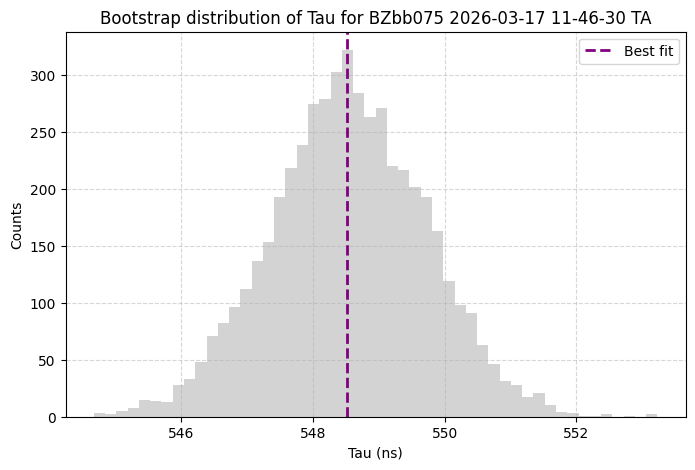

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(
    tau_boot,
    bins=50,
    facecolor='#D3D3D3',     # inside of bars
    #edgecolor='white',   # purple outline
    linewidth=1.5,         # thickness of the outline
    alpha=1.0              # fully opaque inside (white)
)

# Add vertical line for best-fit tau
plt.axvline(tau, color='purple', linestyle='--', linewidth=2, label='Best fit')

plt.xlabel("Tau (ns)")
plt.ylabel("Counts")
plt.title(f"Bootstrap distribution of Tau for {clean_title}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# plt.savefig(
#     f"/content/drive/MyDrive/Colab Notebooks/TRAS/C60_17Mar2026/{clean_title}_Bootstrap_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()


In [7]:
print(A, tau, C)

25.622314911928687 548.5167416186166 1.831252490781724


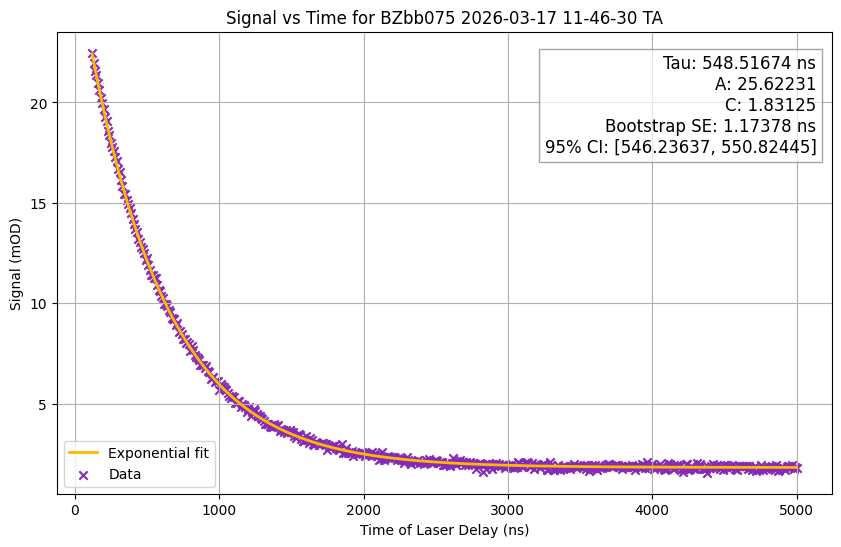


=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 548.51674
Tau bootstrap SE (ns): 1.17378
Tau 95% CI low (ns): 546.23637
Tau 95% CI high (ns): 550.82445


In [8]:
# --- Create fine x-axis for smooth fitted curve ---
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = exp_decay(x_fit, *popt)

plt.figure(figsize=(10, 6))

# Plot the exponential fit
plt.plot(x_fit, y_fit, color='#FFB700', linewidth=2, label='Exponential fit')

# Plot the data points
plt.scatter(x, y, marker='x', color='#852AB8', label='Data')



# Title and labels
plt.title(f'Signal vs Time for {clean_title}')
plt.xlabel('Time of Laser Delay (ns)')
plt.ylabel('Signal (mOD)')

# Add best-fit parameters as text
plt.text(
    0.98, 0.95,
    f'Tau: {tau:.5f} ns\nA: {A:.5f}\nC: {C:.5f}\nBootstrap SE: {tau_std:.5f} ns\n95% CI: [{ci_low:.5f}, {ci_high:.5f}]',
    transform=plt.gca().transAxes,  # axes coordinates
    ha='right',
    va='top',
    fontsize=12,
    color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.legend()
plt.grid(True)

# Save figure
# plt.savefig(
#     f"/content/drive/MyDrive/Colab Notebooks/TRAS/C60_17Mar2026/{clean_title}_signal_vs_time.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# --- Output values for Stern-Volmer preparation ---
print("\n=== Stern–Volmer preparation values ===")
print(f"Concentration (you fill manually per sample): [insert here]")
print(f"Tau value (ns): {tau:.5f}")
print(f"Tau bootstrap SE (ns): {tau_std:.5f}")
print(f"Tau 95% CI low (ns): {ci_low:.5f}")
print(f"Tau 95% CI high (ns): {ci_high:.5f}")


# Values Obtained
=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): BZbb1
Tau value (ns): 521.52045
Tau bootstrap SE (ns): 1.04737
Tau 95% CI low (ns): 519.44798
Tau 95% CI high (ns): 523.61485

=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): BZbb075
Tau value (ns): 548.51674
Tau bootstrap SE (ns): 1.16395
Tau 95% CI low (ns): 546.21887
Tau 95% CI high (ns): 550.78683

=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): BZbb05
Tau value (ns): 620.95671
Tau bootstrap SE (ns): 1.59168
Tau 95% CI low (ns): 617.85350
Tau 95% CI high (ns): 624.19873

=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 722.89255
Tau bootstrap SE (ns): 1.58243
Tau 95% CI low (ns): 719.87638
Tau 95% CI high (ns): 726.01809

In [9]:
# unc_from_base = 0.1**2
# base2 = np.array([1, 0.75, 0.5, 0.25])
# solvent = np.array([1e-12, 0.25, 0.5, 0.75])


# conc_err = np.sqrt(
#     unc_from_base +
#     (0.1/base2)**2 +
#     (0.1/solvent)**2
# )

# conc_err[0] = np.sqrt(2)/10
# print(conc_err)



## Stern Volmer plot
Described on page 22 of the physical manual, gradient gives k_q

Stern–Volmer slope (Ksv): 7.26039e-04 1/ns·mM ± 3.94185e-05
Intercept: 1.22981e-03


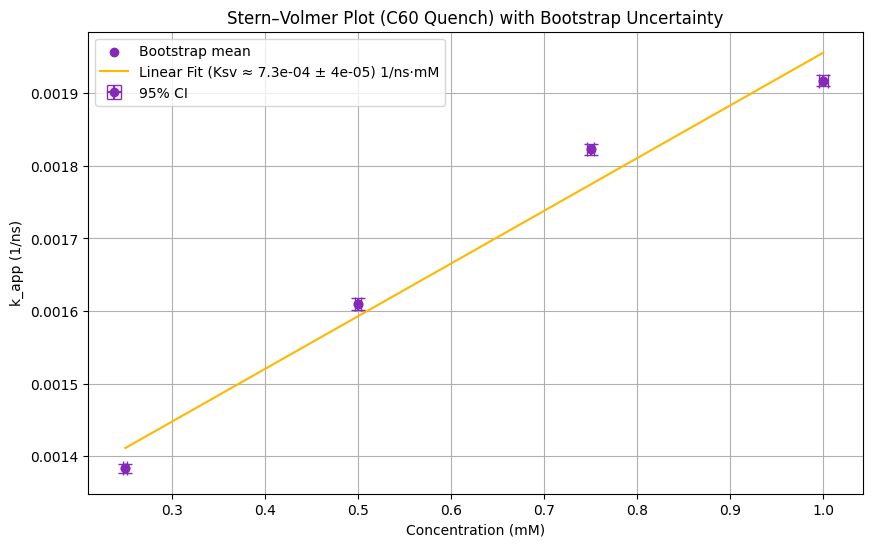

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
concentrations = np.array([1.0, 0.75, 0.5, 0.25])
conc_errors = np.array([4.7*10**(-3), 4.1*10**(-3), 3.4*10**(-3), 2.4*10**(-3)])

tau_values = np.array([521.52045, 548.51674, 620.95671, 722.89255])
tau_std_values = np.array([1.04737, 1.16395, 1.59168, 1.58243])

tau_CI_low = np.array([519.44798, 546.21887, 617.85350, 719.87638])
tau_CI_high = np.array([523.61485, 550.78683, 624.19873, 726.01809])

# -----------------------------
# Derived quantities
# -----------------------------
k_app = 1 / tau_values
k_app_SE = tau_std_values / (tau_values**2)

k_app_CI_low = 1 / tau_CI_high
k_app_CI_high = 1 / tau_CI_low

# -----------------------------
# Linear fit (Stern–Volmer)
# -----------------------------
coeff = np.polyfit(concentrations, k_app, 1)
k_sv_slope = coeff[0]
intercept = coeff[1]

# Rough slope uncertainty
k_app_CI_width = k_app_CI_high - k_app_CI_low
k_sv_slope_error = np.sqrt(
    np.sum((k_app_CI_width / (concentrations.max() - concentrations.min()))**2)
)

print(f"Stern–Volmer slope (Ksv): {k_sv_slope:.5e} 1/ns·mM ± {k_sv_slope_error:.5e}")
print(f"Intercept: {intercept:.5e}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.scatter(concentrations, k_app, color='#852AB8', label='Bootstrap mean', zorder=5)

plt.errorbar(
    concentrations,
    k_app,
    xerr=conc_errors,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o',
    color='#852AB8',
    capsize=5,
    label='95% CI',
    zorder=4
)

x_fit = np.linspace(concentrations.min(), concentrations.max(), 100)
plt.plot(
    x_fit,
    np.polyval(coeff, x_fit),
    color='#FFB700',
    label=f'Linear Fit (Ksv ≈ {k_sv_slope:.1e} ± {k_sv_slope_error:.0e}) 1/ns·mM'
)

plt.xlabel("Concentration (mM)")
plt.ylabel("k_app (1/ns)")
plt.title("Stern–Volmer Plot (C60 Quench) with Bootstrap Uncertainty")
plt.grid(True)
plt.legend()

# Save figure
# plt.savefig(
#     "/content/drive/MyDrive/Colab Notebooks/TRAS/C60_17Mar2026/C60_SternVolmer.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [11]:
# Use symmetric errors from CI for chi-square
k_app_sigma = (k_app_CI_high - k_app_CI_low) / 2

# Model predictions
k_fit = np.polyval(coeff, concentrations)

# Chi-squared
chi2 = np.sum(((k_app - k_fit) / k_app_sigma)**2)

# Degrees of freedom: N - number of parameters (slope + intercept = 2)
dof = len(concentrations) - 2

# Reduced chi-squared
chi2_red = chi2 / dof

print(f"Chi-squared: {chi2:.3f}")
print(f"Reduced Chi-squared: {chi2_red:.3f}")

Chi-squared: 93.612
Reduced Chi-squared: 46.806


In [12]:
# import os
# import numpy as np
# import pandas as pd
# from matplotlib import pyplot as plt
# from scipy.optimize import minimize, nnls

# from google.colab import drive
# rootpathdrive = '/content/drive'
# drive.mount(rootpathdrive)

# # ============================================================
# # !! USER SETTINGS !!
# # ============================================================
# pathTRAS = rootpathdrive + '/' + 'My Drive/Colab Notebooks/TRAS/C60_17Mar2026'

# CONCENTRATION_MAP = {
#     'BZbb1':    1.0,
#     'BZbb075':  0.75,
#     'BZbb05':   0.5,
#     'BZbb025':  0.25,
# }

# ILT_METHOD = 'tikhonov'
# LAMBDA_REG = 0.01
# TAU_MIN    = 1.0
# TAU_MAX    = 20000.0
# N_TAU      = 200

# # ============================================================
# # SECTION 1 — Load & preprocess
# # ============================================================
# def load_csv(filepath):
#     df = pd.read_csv(filepath, sep=";", header=None, names=["time", "signal"])
#     df = df[pd.to_numeric(df["time"], errors="coerce").notna()].reset_index(drop=True)
#     df = df.astype(float)
#     idx_peak = df["signal"].idxmax()
#     df = df.loc[idx_peak:].reset_index(drop=True)
#     return df["time"].to_numpy(), df["signal"].to_numpy()

# # ============================================================
# # SECTION 2 — ILT
# # ============================================================
# def build_kernel(t_data, tau_grid):
#     return np.exp(-t_data[:, np.newaxis] / tau_grid[np.newaxis, :])

# def ilt_tikhonov(t_data, signal, tau_grid, lam=LAMBDA_REG):
#     K   = build_kernel(t_data, tau_grid)
#     KtK = K.T @ K
#     reg = lam * np.eye(len(tau_grid))
#     try:
#         g = np.linalg.solve(KtK + reg, K.T @ signal)
#     except np.linalg.LinAlgError:
#         g = np.linalg.pinv(KtK + reg) @ (K.T @ signal)
#     return np.maximum(g, 0)

# def ilt_nnls(t_data, signal, tau_grid):
#     K    = build_kernel(t_data, tau_grid)
#     g, _ = nnls(K, signal)
#     return g

# def ilt_maxent(t_data, signal, tau_grid, alpha=0.1, max_iter=200):
#     K = build_kernel(t_data, tau_grid)
#     def objective(g):
#         return np.sum((signal - K @ g)**2) + alpha * np.sum(g * np.log(g + 1e-10))
#     def gradient(g):
#         return -2 * K.T @ (signal - K @ g) + alpha * (np.log(g + 1e-10) + 1)
#     g0     = np.ones(len(tau_grid)) / len(tau_grid)
#     result = minimize(objective, g0, jac=gradient, method='L-BFGS-B',
#                       bounds=[(0, None)] * len(tau_grid),
#                       options={'maxiter': max_iter})
#     return result.x

# def run_ilt(time, signal, method=ILT_METHOD):
#     sig_norm = signal / np.max(signal[:10])
#     tau_grid = np.logspace(np.log10(TAU_MIN), np.log10(TAU_MAX), N_TAU)

#     if method == 'tikhonov':
#         g = ilt_tikhonov(time, sig_norm, tau_grid)
#     elif method == 'nnls':
#         g = ilt_nnls(time, sig_norm, tau_grid)
#     elif method == 'maxent':
#         g = ilt_maxent(time, sig_norm, tau_grid)
#     else:
#         raise ValueError("method must be 'tikhonov', 'nnls', or 'maxent'")

#     K             = build_kernel(time, tau_grid)
#     reconstructed = K @ g
#     residuals     = sig_norm - reconstructed

#     total_weight = np.sum(g)
#     mean_tau     = np.sum(tau_grid * g) / total_weight if total_weight > 0 else 0
#     peak_tau     = tau_grid[np.argmax(g)]

#     return dict(
#         tau_grid=tau_grid, g=g,
#         reconstructed=reconstructed, residuals=residuals,
#         sig_norm=sig_norm,
#         mean_tau=mean_tau, peak_tau=peak_tau,
#     )

# # ============================================================
# # SECTION 3 — Per-sample plot
# # ============================================================
# def plot_sample(name, time, signal, ilt, save_dir):
#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     fig.suptitle(name, fontsize=13, fontweight='bold')

#     # Data + ILT reconstruction
#     ax = axes[0]
#     ax.scatter(time, ilt['sig_norm'], marker='x', color='#852AB8',
#                s=10, label='Data (norm)', zorder=3)
#     ax.plot(time, ilt['reconstructed'], color='steelblue',
#             linewidth=2, label='ILT reconstruction')
#     ax.set_xlabel('Time (ns)'); ax.set_ylabel('Normalised signal')
#     ax.set_title('ILT reconstruction')
#     ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

#     # ILT lifetime distribution
#     ax = axes[1]
#     ax.semilogx(ilt['tau_grid'], ilt['g'], color='steelblue', linewidth=2)
#     ax.axvline(ilt['mean_tau'], color='red',   linestyle='--', linewidth=1.5,
#                label=f"Mean τ = {ilt['mean_tau']:.1f} ns")
#     ax.axvline(ilt['peak_tau'], color='green', linestyle=':',  linewidth=1.5,
#                label=f"Peak τ = {ilt['peak_tau']:.1f} ns")
#     ax.set_xlabel('τ (ns)'); ax.set_ylabel('Amplitude g(τ)')
#     ax.set_title(f'ILT distribution ({ILT_METHOD})')
#     ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

#     # Residuals
#     ax = axes[2]
#     ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
#     ax.scatter(time, ilt['residuals'], marker='.', color='steelblue',
#                s=8, alpha=0.6)
#     ax.fill_between(time, ilt['residuals'], alpha=0.2, color='steelblue')
#     rms = np.sqrt(np.mean(ilt['residuals']**2))
#     ax.set_xlabel('Time (ns)'); ax.set_ylabel('Residual')
#     ax.set_title('ILT residuals')
#     ax.text(0.97, 0.05, f'RMS = {rms:.5f}',
#             transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
#             bbox=dict(facecolor='white', alpha=0.8, edgecolor='#ccc'))
#     ax.grid(True, alpha=0.3)

#     plt.tight_layout()
#     out_path = os.path.join(save_dir, f"{name}_ILT.png")
#     plt.savefig(out_path, dpi=300, bbox_inches='tight')
#     plt.show()
#     print(f"  Saved → {out_path}")

# # ============================================================
# # SECTION 4 — ILT overlay
# # ============================================================
# def plot_ilt_overlay(ilt_results, save_dir):
#     fig, ax = plt.subplots(figsize=(8, 5))
#     colors = plt.cm.viridis(np.linspace(0, 1, len(ilt_results)))

#     for (name, conc, ilt), col in zip(ilt_results, colors):
#         label = next((k for k in CONCENTRATION_MAP if k in name), name)
#         ax.semilogx(ilt['tau_grid'], ilt['g'], color=col, linewidth=2,
#                     label=f'{label} ({conc} mM)')

#     ax.set_xlabel('τ (ns)', fontsize=12)
#     ax.set_ylabel('Amplitude g(τ)', fontsize=12)
#     ax.set_title(f'ILT Lifetime Distributions — all concentrations\n(method: {ILT_METHOD})',
#                  fontsize=12)
#     ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout()

#     out_path = os.path.join(save_dir, 'ILT_overlay.png')
#     plt.savefig(out_path, dpi=300, bbox_inches='tight')
#     plt.show()
#     print(f"  Saved → {out_path}")

# # ============================================================
# # SECTION 5 — MAIN LOOP
# # ============================================================
# all_files = os.listdir(pathTRAS)
# csv_files = sorted([f for f in all_files
#                     if f.endswith('.csv') and 'traces' not in f.lower()])
# print(f"Found {len(csv_files)} CSV files:")
# for f in csv_files:
#     print(f"  {f}")

# samples = []
# for csv_file in csv_files:
#     conc = None
#     for key, val in CONCENTRATION_MAP.items():
#         if key in csv_file:
#             conc = val
#             break
#     if conc is None:
#         print(f"  WARNING: no concentration match for '{csv_file}' — skipping.")
#         continue
#     samples.append((csv_file.replace('.csv', ''),
#                     os.path.join(pathTRAS, csv_file),
#                     conc))

# samples = sorted(samples, key=lambda s: s[2])
# print(f"\nMatched {len(samples)} samples:")
# for name, _, conc in samples:
#     print(f"  {name}  →  {conc} mM")

# ilt_results = []

# for name, filepath, conc in samples:
#     print(f"\n{'='*62}")
#     print(f"  {name}  ({conc} mM)")
#     print(f"{'='*62}")

#     time, signal = load_csv(filepath)
#     print(f"  {len(time)} points  (t = {time[0]:.2f} … {time[-1]:.2f} ns)")

#     print(f"  Running ILT ({ILT_METHOD}) …")
#     ilt = run_ilt(time, signal)
#     print(f"  Mean τ = {ilt['mean_tau']:.1f} ns   Peak τ = {ilt['peak_tau']:.1f} ns")

#     plot_sample(name, time, signal, ilt, pathTRAS)
#     ilt_results.append((name, conc, ilt))

# print(f"\n{'='*62}\n  ILT overlay\n{'='*62}")
# plot_ilt_overlay(ilt_results, pathTRAS)

# # Summary table
# print(f"\n{'='*62}\n  SUMMARY TABLE\n{'='*62}")
# rows = [{'Sample': name, '[Q] (mM)': conc,
#          'ILT peak τ (ns)': round(ilt['peak_tau'], 1),
#          'ILT mean τ (ns)': round(ilt['mean_tau'], 1)}
#         for name, conc, ilt in ilt_results]
# print(pd.DataFrame(rows).to_string(index=False))